# Data provisioning

#### Previous notebook: [Data collection](01_data_collection.ipynb)

## Split labels into separate columns
In the original `disaster_categories.csv` file all labels per message are stored as a single string in the *categories* column, separated by semicolons. In this step, I split the labels into different columns, one per label. This is done to ensure the data is stored in a suitable format for converting each label values into numeric data type:

In [31]:
import pandas as pd

df_categories = pd.read_csv("../data/raw/original/disaster_categories.csv")
cats = df_categories[["id", "categories"]].copy()
cats_expanded = cats["categories"].str.split(";", expand=True)
row = cats_expanded.iloc[0]
category_colnames = row.apply(lambda x: x.split("-")[0])
cats_expanded.columns = category_colnames
categories = pd.concat([cats["id"], cats_expanded], axis=1)
categories.head()

,id,related,request,offer,aid_related,medical_help,medical_products,search_and_rescue,security,military,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,2,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
1,7,related-1,request-0,offer-0,aid_related-1,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-1,floods-0,storm-1,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
2,8,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
3,9,related-1,request-1,offer-0,aid_related-1,medical_help-0,medical_products-1,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
4,12,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0


As we can see from the output above, the categories column is now separated in multiple small label-based columns. Each column stores the name of the label and a binary number that represents whether the label applies to the message (1) or not (0).

## Convert columns to numeric values
In this step, I go through all *label - number* values, remove the text, keep only the numeric value and cast it into an integer to ensure all target variables are correctly stored:

In [32]:
for column in categories.columns:
    if column != "id":
        categories[column] = categories[column].str.split("-").str[-1].astype(int)

print(categories.shape)
print(categories.info())

(26248, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26248 entries, 0 to 26247
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      26248 non-null  int64
 1   related                 26248 non-null  int64
 2   request                 26248 non-null  int64
 3   offer                   26248 non-null  int64
 4   aid_related             26248 non-null  int64
 5   medical_help            26248 non-null  int64
 6   medical_products        26248 non-null  int64
 7   search_and_rescue       26248 non-null  int64
 8   security                26248 non-null  int64
 9   military                26248 non-null  int64
 10  child_alone             26248 non-null  int64
 11  water                   26248 non-null  int64
 12  food                    26248 non-null  int64
 13  shelter                 26248 non-null  int64
 14  clothing                26248 non-null  int64
 15  money  

From the output above, we can see that after splitting and casting, the categories dataset consists of 26 248 rows and 37 columns - one id column and 36 labels, all integers. This ensures all labels were properly separated as its current count equals the original dataset documentation.

## Check all unique values per column
After converting all column values to integers, I will go through all columns, except the id, and store all unique values per label to verify whether all columns contain binary values (1 and 0):

In [33]:
binary_check = {}

for col in categories.columns:
    if col == "id":
        continue
    vals = sorted(categories[col].unique().tolist())
    binary_check[col] = vals

binary_check

{'related': [0, 1, 2],
 'request': [0, 1],
 'offer': [0, 1],
 'aid_related': [0, 1],
 'medical_help': [0, 1],
 'medical_products': [0, 1],
 'search_and_rescue': [0, 1],
 'security': [0, 1],
 'military': [0, 1],
 'child_alone': [0],
 'water': [0, 1],
 'food': [0, 1],
 'shelter': [0, 1],
 'clothing': [0, 1],
 'money': [0, 1],
 'missing_people': [0, 1],
 'refugees': [0, 1],
 'death': [0, 1],
 'other_aid': [0, 1],
 'infrastructure_related': [0, 1],
 'transport': [0, 1],
 'buildings': [0, 1],
 'electricity': [0, 1],
 'tools': [0, 1],
 'hospitals': [0, 1],
 'shops': [0, 1],
 'aid_centers': [0, 1],
 'other_infrastructure': [0, 1],
 'weather_related': [0, 1],
 'floods': [0, 1],
 'storm': [0, 1],
 'fire': [0, 1],
 'earthquake': [0, 1],
 'cold': [0, 1],
 'other_weather': [0, 1],
 'direct_report': [0, 1]}

As we can see from the results above, the most columns contain binary values, except for the *related* one which consists of the numbers 0,1 and 2. Additionally, we can see that the *child_alone* column only consists of 0, which is a clear indication that this label will be removed later as it does not apply to any of the messages and does not bring any valuable information for the training stage.

In the original dataset documentation, it is mentioned that the 2s in the column *related* represent the answer "unsure" for messages that cannot be clearly categorized. Due to the sensitivity of the child-related messages and the potential risk of developing a model that could identify at-risk minors all *child_alone* annotations are 0.

## Check all labels of the non-binary samples
To get a better understanding of what the "unsure" messages represent, I will extract all labels for those specific messages and check their annotations to understand whether they behave as related and have other needs or completely act as a completely separate category:

In [34]:
rel2 = categories[categories["related"] == 2].copy()
other_cols = [c for c in categories.columns if c not in ["id", "related"]]
rel2["other_positive"] = rel2[other_cols].gt(0).any(axis=1)
print(rel2["other_positive"].value_counts())

other_positive
False    193
Name: count, dtype: int64


The results above show that all other labels of those "unsure" messages are negative and do not provide information about any specific help needed. To ensure all labels are in a binary format and are properly annotated, I will remove those samples.

### Check binary vs non-binary sample distribution
Before dropping the examples from the dataset, I will calculate the % of Binary vs Non-binary "related" labels, to check and document how much data I will lose:

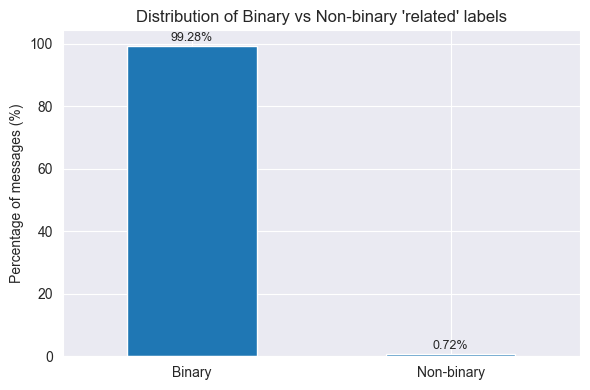

In [35]:
import matplotlib.pyplot as plt

related_2_rows = categories[categories["related"] == 2]
ids_related_2 = related_2_rows["id"].unique()
total_ids = categories["id"].nunique()
non_binary_ids = len(ids_related_2)
binary_ids = total_ids - non_binary_ids
counts = pd.Series({"Binary": binary_ids,"Non-binary": non_binary_ids})
counts_pct = counts / counts.sum() * 100

plt.figure(figsize=(6, 4))
ax = counts_pct.plot(kind="bar")
plt.title("Distribution of Binary vs Non-binary 'related' labels")
plt.ylabel("Percentage of messages (%)")
plt.xticks(rotation=0)
for i, v in enumerate(counts_pct):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

The bar chart above shows that the messages with *related = 2* represent a very small proportion (0.72%) of the whole dataset, which clearly indicates that the value behaves as an outlier class. Removing these rows will not introduce substantial data loss and will keep *related* category easier to interpret for modeling.

## Drop non-binary samples
In this step, I will drop all *related = 2* rows and check the remaining binary distribution:

In [36]:
ids_to_drop = rel2["id"].unique()
categories_clean = categories[~categories["id"].isin(ids_to_drop)].copy()
categories_clean["related"].value_counts()

related
1    19929
0     6125
Name: count, dtype: int64

After removing the "unsure" samples, the *related* column consists of 19 929 related messages and 6 125 not related. The results confirm that all non-binary rows were removed from the dataset.

## Label aggregation
In the [Data collection notebook](01_data_collection.ipynb) were detected 68 duplicate in both `disaster_messages.csv` and `disaster_categories.csv`. The duplicates appear because one message was annotated by more than one person. To address this problem, I decided to apply aggregation, which combines all labels from duplicates related to a specific message. If a label was marked as positive in at least one row will remain positive in the final label vector:

In [37]:
categories_agg = categories_clean.groupby("id", as_index=False).max()
categories_agg.to_csv("../data/raw/removed_duplicates/disaster_categories.csv", index=False)
print("Duplicate ids after aggregation:",categories_agg["id"].duplicated().sum())

Duplicate ids after aggregation: 0


To ensure that the label aggregation was applied successfully, I print the sum of all detected duplicates, which in this case is 0. The deduplicated file is saved in a sub-folder called `removed_duplicates`.

## Inspect file
In this step, I will inspect the deduplicated categories dataset to confirm the final shape and data types before merging it with the `disaster_messages.csv`:

In [38]:
print(categories_agg.shape)
print(categories_agg.info())

(25992, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25992 entries, 0 to 25991
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      25992 non-null  int64
 1   related                 25992 non-null  int64
 2   request                 25992 non-null  int64
 3   offer                   25992 non-null  int64
 4   aid_related             25992 non-null  int64
 5   medical_help            25992 non-null  int64
 6   medical_products        25992 non-null  int64
 7   search_and_rescue       25992 non-null  int64
 8   security                25992 non-null  int64
 9   military                25992 non-null  int64
 10  child_alone             25992 non-null  int64
 11  water                   25992 non-null  int64
 12  food                    25992 non-null  int64
 13  shelter                 25992 non-null  int64
 14  clothing                25992 non-null  int64
 15  money  

In [39]:
categories_agg.head()

,id,related,request,offer,aid_related,medical_help,medical_products,search_and_rescue,security,military,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,1,0,0,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,8,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,1,1,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The results above show that, after aggregation, the `disaster_categories.csv` consists of 25 992 labels and 37 columns - all integers. All labels are split in separate columns and have binary values, which indicates that the two files are ready to be merged.

## Check messages with vs without labels distribution
Before merging the two disaster datasets, I will create a simple bar chart to visualize the distribution of messages with vs without labels. This step is important, as it reports the percentage of messages that will be lost after applying inner join.

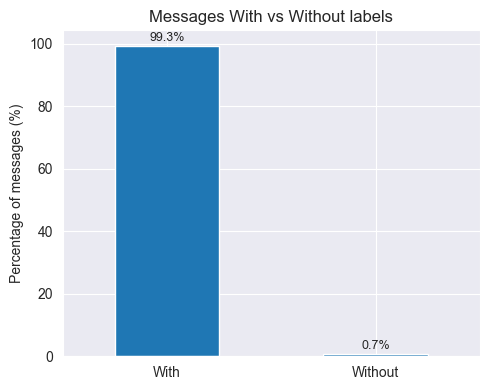

In [40]:
msg = pd.read_csv("../data/raw/removed_duplicates/disaster_messages.csv")
cat = pd.read_csv("../data/raw/removed_duplicates/disaster_categories.csv")
n_total = msg["id"].nunique()
ids_with_cat = set(cat["id"])
n_with = msg["id"].isin(ids_with_cat).sum()
n_without = n_total - n_with
counts = pd.Series({"With": n_with,"Without": n_without})
counts_pct = counts / counts.sum() * 100

plt.figure(figsize=(5, 4))
ax = counts_pct.plot(kind="bar")
plt.title("Messages With vs Without labels")
plt.ylabel("Percentage of messages (%)")
plt.xticks(rotation=0)

for i, v in enumerate(counts_pct):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

The bar chart above shows that a very small fraction (0.7%) of messages do not have labels. This indicates  that the data loss after merging is minimal and acceptable.

## Merge disaster dataset
In this step, I will merge the two deduplicated disaster files on their shared *id* column. I will use inner join, which will automatically drop all messages that do not have labels in the category dataset. Finally, I will inspect the structure of the raw disaster dataset and save it to ensure the file can be reused in other notebooks:

In [41]:
from functools import reduce

dfs = [msg, cat]
disaster_df = reduce(lambda left, right: pd.merge(left, right, on="id", how="inner"), dfs)
print(disaster_df.shape)
print(disaster_df.info())

(25992, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25992 entries, 0 to 25991
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      25992 non-null  int64 
 1   message                 25992 non-null  object
 2   original                10021 non-null  object
 3   genre                   25992 non-null  object
 4   related                 25992 non-null  int64 
 5   request                 25992 non-null  int64 
 6   offer                   25992 non-null  int64 
 7   aid_related             25992 non-null  int64 
 8   medical_help            25992 non-null  int64 
 9   medical_products        25992 non-null  int64 
 10  search_and_rescue       25992 non-null  int64 
 11  security                25992 non-null  int64 
 12  military                25992 non-null  int64 
 13  child_alone             25992 non-null  int64 
 14  water                   25992 non-null  in

In [42]:
disaster_df.to_csv("../data/raw/disaster_dataset.csv", index=False)
disaster_df.head()

,id,message,original,genre,related,request,offer,aid_related,medical_help,medical_products,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,2,Weather update - a cold front from Cuba that c...,Un front froid se retrouve sur Cuba ce matin. ...,direct,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,Is the Hurricane over or is it not over,Cyclone nan fini osinon li pa fini,direct,1,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,0
2,8,Looking for someone but no name,"Patnm, di Maryani relem pou li banm nouvel li ...",direct,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,UN reports Leogane 80-90 destroyed. Only Hospi...,UN reports Leogane 80-90 destroyed. Only Hospi...,direct,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,12,"says: west side of Haiti, rest of the country ...",facade ouest d Haiti et le reste du pays aujou...,direct,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The results show that the raw merged dataset consists of 25 992 rows and 40 columns - one unique identifier, the message in its original language and in English, the genre of the message and 36 binary labels (0/1). Most of the columns in the dataset have numeric data type and only 3 - *message, original* and *genre* are stored as text. To read more about the structure of the dataset check: [disaster dataset dictionary](../docs/Data%20dictionary.md).

## Data quality check before cleaning
#### Messages per label

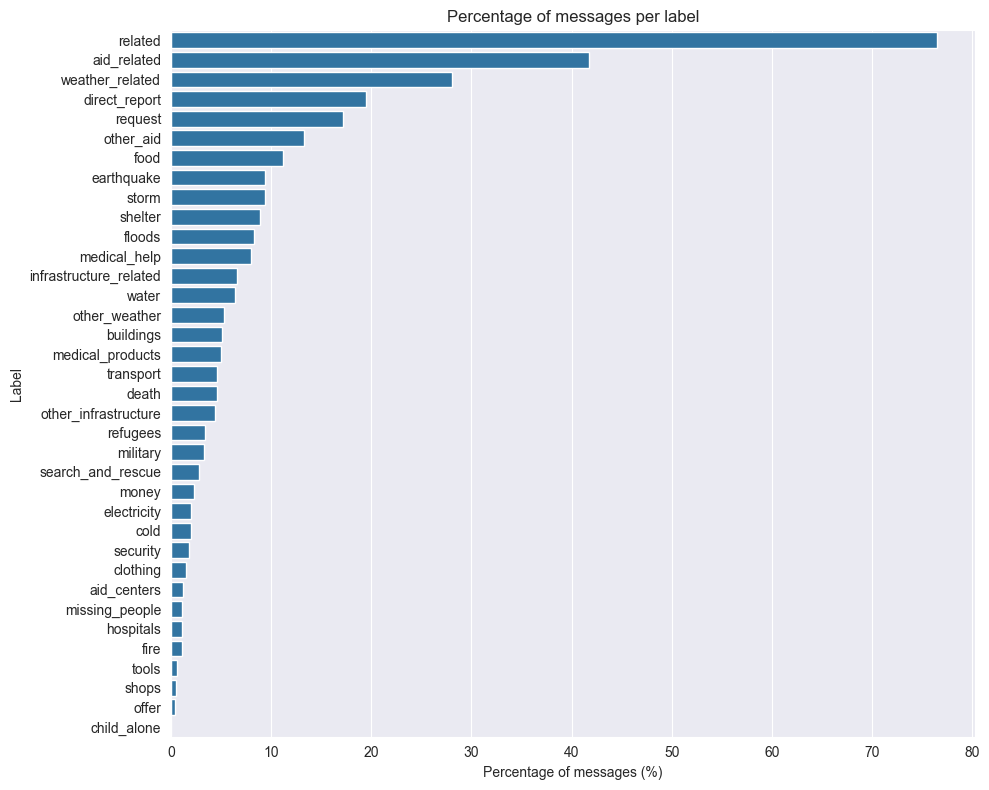

In [43]:
import seaborn as sns
from utilities import helper

label_pct = helper.calculate_label_message_percentage(disaster_df)

plt.figure(figsize=(10, 8))
sns.barplot(x=label_pct.values,y=label_pct.index)
plt.xlabel("Percentage of messages (%)")
plt.ylabel("Label")
plt.title("Percentage of messages per label")
plt.tight_layout()
plt.show()

#### Labels per message

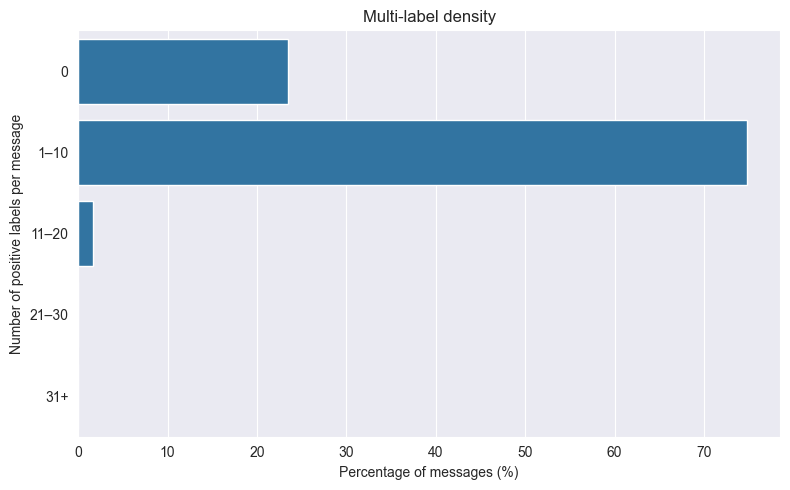

In [44]:
from utilities import helper

label_cols = helper.get_label_columns(disaster_df)
disaster_df["n_labels"] = disaster_df[label_cols].sum(axis=1)
max_possible = len(label_cols)
bins = [-0.1, 0.5, 10.5, 20.5, 30.5, max_possible + 0.5]
range_labels = ["0", "1–10", "11–20", "21–30", "31+"]
disaster_df["label_range"] = pd.cut(disaster_df["n_labels"],bins=bins,labels=range_labels,include_lowest=True)
range_counts = disaster_df["label_range"].value_counts().sort_index()
range_pct = (range_counts / len(disaster_df) * 100).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=range_pct.values,y=range_pct.index,orient="h")
plt.xlabel("Percentage of messages (%)")
plt.ylabel("Number of positive labels per message")
plt.title("Multi-label density")
plt.tight_layout()
plt.show()

#### Check missingness

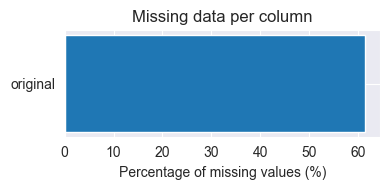

In [45]:
missing_pct = disaster_df.isna().mean().mul(100).round(2)
missing_pct_nonzero = missing_pct[missing_pct > 0]

plt.figure(figsize=(4, 2))
plt.barh(missing_pct_nonzero.index, missing_pct_nonzero.values)
plt.xlabel("Percentage of missing values (%)")
plt.title("Missing data per column")
plt.tight_layout()
plt.show()

#### Check message length

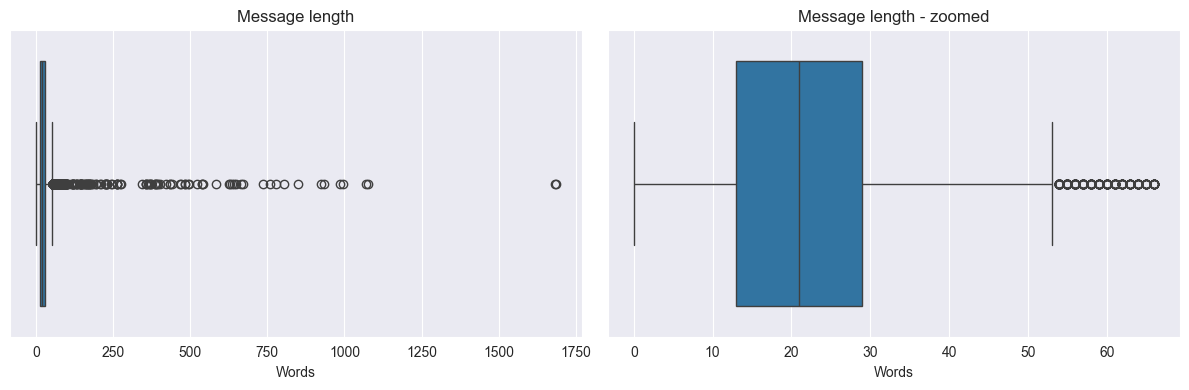

In [46]:
disaster_df["msg_len"] = disaster_df["message"].str.split().str.len()
p99 = disaster_df["msg_len"].quantile(0.99)
short_df = disaster_df[disaster_df["msg_len"] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=disaster_df["msg_len"], ax=axes[0])
axes[0].set_title("Message length")
axes[0].set_xlabel("Words")

sns.boxplot(x=short_df["msg_len"], ax=axes[1])
axes[1].set_title("Message length - zoomed")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

In [47]:
word_stats = disaster_df["msg_len"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])
print(word_stats)

count    25992.000000
mean        23.892929
std         32.297461
min          0.000000
1%           5.000000
5%           7.000000
50%         21.000000
95%         45.000000
99%         66.000000
max       1686.000000
Name: msg_len, dtype: float64


In [48]:
short_mask = disaster_df["msg_len"] <=2
long_mask  = disaster_df["msg_len"] >= 100
n_total = len(disaster_df)
n_short = short_mask.sum()
n_long  = long_mask.sum()

print(f"Extremely short: {n_short}")
print(f"Extremely long: {n_long}")

Extremely short: 13
Extremely long: 108


In [49]:
disaster_df.loc[short_mask, ["message"]]

,message
6736,paklascencion##s
7621,"world visionw.agency.usaid,pam"
8310,Aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa...
8775,Nokia.com http://ea.mobile.nokia.com/ea/graphics
12051,
12080,PIDE .
15502,(http://www.guardian.co.uk/global-development/...
16327,#NAME?
21216,Website: http://www.childfund.org/emergency_up...
21326,See http://www.iwpr.net/index.pl?local_caucasu...


In [50]:
disaster_df.loc[long_mask, ["message"]].sample(3)

,message
22923,"Discarding the current, impromptu response, we..."
24708,It is hard to stay here; life is doubly diffic...
11078,The JCC of stamford has collected a LOT of cle...


#### English vs Non-English original messages

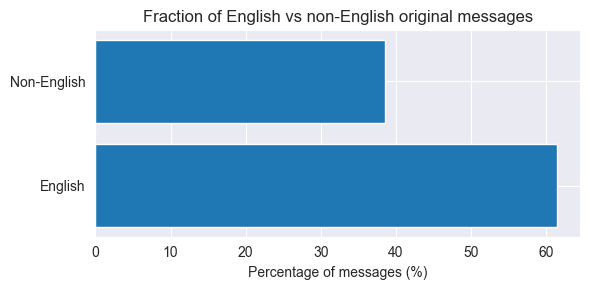

In [51]:
disaster_df["is_non_english"] = disaster_df["original"].notna()
lang_counts = disaster_df["is_non_english"].value_counts()
lang_counts.index = lang_counts.index.map({False: "English",True:  "Non-English"})
lang_pct = (lang_counts / len(disaster_df) * 100).round(2)

plt.figure(figsize=(6, 3))
plt.barh(lang_pct.index, lang_pct.values)
plt.xlabel("Percentage of messages (%)")
plt.title("Fraction of English vs non-English original messages")
plt.tight_layout()
plt.show()

#### Label correlation

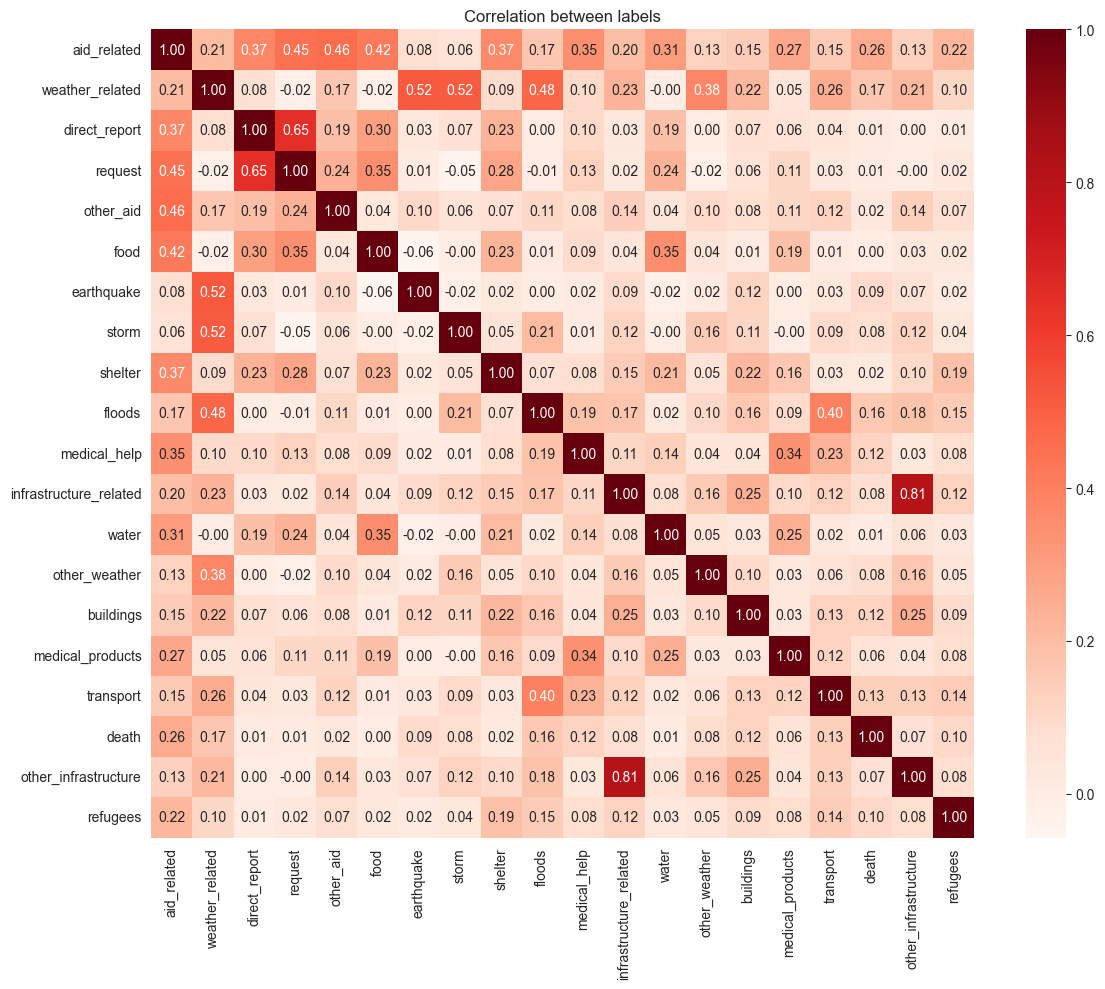

In [52]:
disaster_df = pd.read_csv("../data/raw/disaster_dataset.csv", low_memory=False)
non_label_cols = ["id", "message", "original", "genre"]
label_cols = [c for c in disaster_df.columns if c not in non_label_cols]
label_cols_no_related = [c for c in label_cols if c != "related"]
label_counts = disaster_df[label_cols_no_related].sum().sort_values(ascending=False)
top_labels = label_counts.head(20).index.tolist()

corr_small = disaster_df[top_labels].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_small,cmap="Reds", annot=True, fmt=".2f")
plt.title("Correlation between labels")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Cleaning dataset

In [53]:
cols_to_drop = ["child_alone", "original", "fire", "tools", "offer", "shops"]
disaster_df = disaster_df.drop(columns=cols_to_drop)
keep_mask = ~short_mask & ~long_mask
disaster_clean = disaster_df.loc[keep_mask].copy()

print(disaster_clean.shape)
disaster_clean.info()

(25871, 34)
<class 'pandas.core.frame.DataFrame'>
Index: 25871 entries, 0 to 25991
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      25871 non-null  int64 
 1   message                 25871 non-null  object
 2   genre                   25871 non-null  object
 3   related                 25871 non-null  int64 
 4   request                 25871 non-null  int64 
 5   aid_related             25871 non-null  int64 
 6   medical_help            25871 non-null  int64 
 7   medical_products        25871 non-null  int64 
 8   search_and_rescue       25871 non-null  int64 
 9   security                25871 non-null  int64 
 10  military                25871 non-null  int64 
 11  water                   25871 non-null  int64 
 12  food                    25871 non-null  int64 
 13  shelter                 25871 non-null  int64 
 14  clothing                25871 non-null  int64 


#### Check missingness after cleaning

In [54]:
disaster_clean.isna().mean().sort_values(ascending=False)

id                        0.0
message                   0.0
genre                     0.0
related                   0.0
request                   0.0
aid_related               0.0
medical_help              0.0
medical_products          0.0
search_and_rescue         0.0
security                  0.0
military                  0.0
water                     0.0
food                      0.0
shelter                   0.0
clothing                  0.0
money                     0.0
missing_people            0.0
refugees                  0.0
death                     0.0
other_aid                 0.0
infrastructure_related    0.0
transport                 0.0
buildings                 0.0
electricity               0.0
hospitals                 0.0
aid_centers               0.0
other_infrastructure      0.0
weather_related           0.0
floods                    0.0
storm                     0.0
earthquake                0.0
cold                      0.0
other_weather             0.0
direct_rep

#### Check label distribution

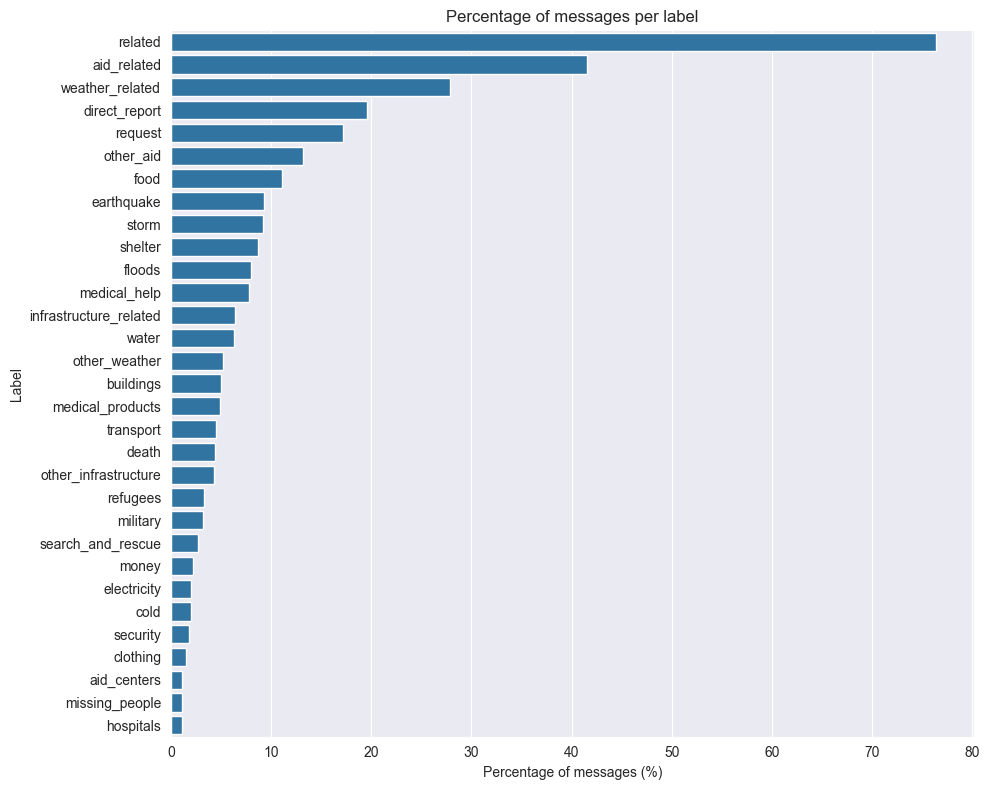

In [55]:
from utilities import helper

label_pct = helper.calculate_label_message_percentage(disaster_clean)
plt.figure(figsize=(10, 8))
sns.barplot(x=label_pct.values,y=label_pct.index)
plt.xlabel("Percentage of messages (%)")
plt.ylabel("Label")
plt.title("Percentage of messages per label")
plt.tight_layout()
plt.show()

#### Check message length

In [56]:
word_len_clean = disaster_clean["message"].str.split().str.len()
word_len_clean.describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    25871.000000
mean        22.429941
std         11.931418
min          3.000000
1%           5.000000
5%           7.000000
50%         21.000000
95%         44.000000
99%         60.000000
max         97.000000
Name: message, dtype: float64